In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("powerplant.csv")


In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
#AT=TEMPERATURE
#V=VACCUM
#AP=PRESSURE
#RH=HUMIDITY
#PE=PRODUCED ENERGY

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X=df.drop("PE",axis=1)
y=df["PE"]

In [8]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [12]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled_train=scaler.fit_transform(X_train)
X_scaled_test=scaler.transform(X_test)

In [13]:
import torch 
import torch.nn as nn

In [15]:
X_train_tensor=torch.tensor(X_scaled_train,dtype=torch.float32)
X_test_tensor=torch.tensor(X_scaled_test,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)


In [17]:
from torch.utils.data import TensorDataset,DataLoader
train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)

In [18]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)


In [38]:
# defining ann
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()
        self.model=nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),
            #2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),
            #output layer
            nn.Linear(6,1),
        )
    def forward(self,x):
        return self.model(x)
        

In [39]:
import torch.optim as optim
model=ANN()
crietrion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

In [40]:
# train the ANN
epochs=100
train_loss=[]
val_loss=[]
best_val_loss=float("inf")
for epoch in range(epochs):
    model.train()
    running_loss=0.0
    for xb,yb in train_loader:
        # xb=1st batch features
        #yb=label of first batch
        optimizer.zero_grad()
        outputs=model(xb)# forward propogation-compute outputs for the batch
        loss=crietrion(outputs,yb)# compute loss
        loss.backward()#backward propogation 
        optimizer.step()#to update the parameters
        running_loss+=loss.item()#loss is a tensor ,to change the tensor into python float
    epoch_train_loss=running_loss/len(train_loader)
    train_loss.append(epoch_train_loss)

#validation
    model.eval()
    running_val_loss=0.0
    with torch.no_grad():
        for xb,yb in test_loader:
            outputs=model(xb)
            loss=crietrion(outputs,yb)
            running_val_loss+=loss.item()
    epoch_test_loss=running_val_loss/len(test_loader)
    val_loss.append(epoch_test_loss)
    print(f"epoch {epoch+1}/{epochs} training loss is{epoch_train_loss}& validation loss is{epoch_test_loss}")
    if epoch_test_loss<best_val_loss:
        best_val_loss=epoch_test_loss
        torch.save(model.state_dict(),"best_model.pt")

epoch 1/100 training loss is206289.7635261194& validation loss is205296.99668560605
epoch 2/100 training loss is200179.13642723882& validation loss is191809.12736742425
epoch 3/100 training loss is175522.22193718905& validation loss is155978.53535353535
epoch 4/100 training loss is131610.071284204& validation loss is107931.97679924243
epoch 5/100 training loss is87185.61650730722& validation loss is70509.38502209596
epoch 6/100 training loss is58769.54784670398& validation loss is49174.33601641414
epoch 7/100 training loss is41299.48509406095& validation loss is33804.44769965278
epoch 8/100 training loss is27444.578737173506& validation loss is21058.164397885103
epoch 9/100 training loss is16325.221359025187& validation loss is11948.384824810606
epoch 10/100 training loss is9342.983323130442& validation loss is7180.776416508838
epoch 11/100 training loss is6108.484292405162& validation loss is5268.054490214647
epoch 12/100 training loss is4696.777921913868& validation loss is4256.03716

Text(0, 0.5, 'losses')

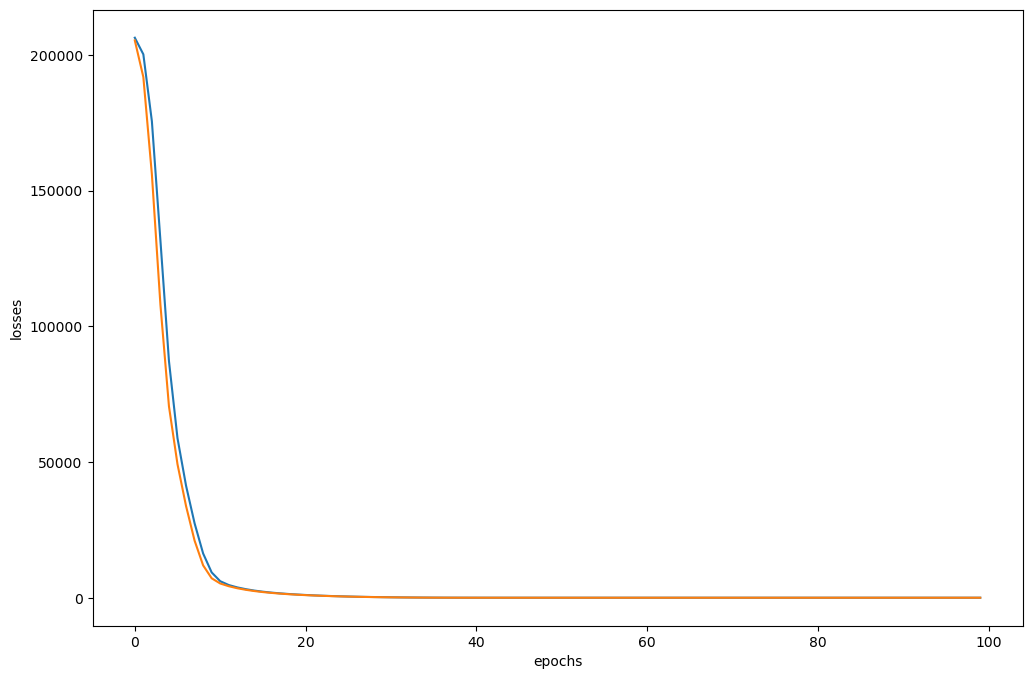

In [41]:
import matplotlib.pyplot as plt
losses_df=pd.DataFrame({
    "training_loss":train_loss,
    "val_loss":val_loss}
    
)
plt.figure(figsize=(12,8))
plt.plot(losses_df["training_loss"] ,label="Training loss")
plt.plot(losses_df["val_loss"] ,label="validation loss")
plt.xlabel("epochs")
plt.ylabel("losses")

In [42]:
#loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [43]:
#evaluating the best model
model.eval()
with torch.no_grad():
    train_pred=model(X_train_tensor)
    test_pred=model(X_test_tensor)
    train_mse_loss=crietrion(train_pred,y_train_tensor)
    test_mse_loss=crietrion(test_pred,y_test_tensor)
print("train MSE:",train_mse_loss.item())
print("test MSE:",test_mse_loss.item())


train MSE: 21.047807693481445
test MSE: 20.228046417236328


In [44]:
from sklearn.metrics import r2_score
print("r^2 score",r2_score(y_test,test_pred))

r^2 score 0.9302074052032356


In [48]:
predicted_df=pd.DataFrame(test_pred.numpy(),columns=["Predicted values"])
actual_df=pd.DataFrame(y_test.values,columns=["actual values"])
pd.concat([predicted_df,actual_df], axis=1)

,Predicted values,actual values
0,435.953644,433.27
1,437.474701,438.16
2,461.366974,458.42
3,476.046783,480.82
4,436.036346,441.41
...,...,...
3153,466.734039,468.45
3154,483.721222,485.24
3155,479.382721,482.83
3156,474.872406,479.14
